# Módulo A — Detección de Emociones
## Notebook 02: Fine-tuning de DistilBERT

**Proyecto:** PROYECTO MONIKA — Asistente de voz con avatar holográfico (inferencia 100% local) 
**Prerequisito:** Haber ejecutado `01_goemotions_data_pipeline.ipynb` — los archivos en `data/` deben existir.

---
### Decisiones de diseño documentadas
- **Modelo:** `distilbert-base-uncased` — 40% menos parámetros que BERT-base, ~60% menos latencia, ~97% del performance en clasificación.
- **Clases:** 12 grupos (esquema de colapso definido en Notebook 01).
- **Desbalance:** compensado con `class_weight='balanced'` → pesos inversos a la frecuencia de cada clase.
- **Modo SMOKE_TEST:** usa 256 ejemplos de train y 64 de val para verificar que el pipeline corre sin errores antes del entrenamiento completo.

## 0. Dependencias

In [1]:
import importlib, subprocess, sys

REQUIRED = {
    'torch':               'torch',
    'transformers':        'transformers',
    'sklearn':             'scikit-learn',
    'pandas':              'pandas',
    'numpy':               'numpy',
    'matplotlib':          'matplotlib',
    'seaborn':             'seaborn',
    'tqdm':                'tqdm',
}

for module, package in REQUIRED.items():
    if importlib.util.find_spec(module) is None:
        print(f'Instalando {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('✓ Todas las dependencias disponibles.')

✓ Todas las dependencias disponibles.


In [ ]:
import os
import json
import random
import logging
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
logging.getLogger('transformers').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plot_style import fig_title  # banner-title toggle (MONIKA_FIG_TITLES)
import matplotlib.patches as mpatches
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

# ── Reproducibilidad total ────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_DIR  = Path('data')
FIG_DIR   = Path('figures')
MODEL_DIR = Path('models')
LOG_DIR   = Path('logs')
for d in [FIG_DIR, MODEL_DIR, LOG_DIR]:
    d.mkdir(exist_ok=True)

# ── Estilo gráficas ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

# ── Dispositivo ───────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Semilla: {SEED}')

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 4060 Ti
  VRAM disponible: 16.7 GB
Semilla: 42


## 1. Configuración del experimento

**Cambiar `SMOKE_TEST = True` → `False` para el entrenamiento completo.**  
Todo el notebook se adapta automáticamente a este flag.

In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║              CONFIGURACIÓN DEL EXPERIMENTO              ║
# ╚══════════════════════════════════════════════════════════╝

SMOKE_TEST = False   # ← cambiar a False para entrenamiento completo

# ── Selección de modelo ───────────────────────────────────────────────────────
# Opciones validadas para clasificación multilingüe:
#   'distilbert-base-uncased'               — inglés, 67M params (baseline)
#   'distilbert-base-multilingual-cased'    — 104 idiomas, 134M params
#   'xlm-roberta-base'                      — 100 idiomas, 278M params
MODEL_NAME = 'distilbert-base-multilingual-cased'

CFG = {
    # ── Modelo ────────────────────────────────────────────
    'model_name':       MODEL_NAME,
    'max_length':       192,      # tokens por ejemplo — cubre los ejemplos largos augmentados

    # ── Entrenamiento ─────────────────────────────────────
    'batch_size':       32,       # 4060Ti 16GB aguanta 32 sin problema
    'epochs':           10  if not SMOKE_TEST else 2,
    'lr':               2e-5,
    'warmup_ratio':     0.10,      # 10% de los steps para warmup
    'weight_decay':     0.05,
    'grad_clip':        1.0,

    # ── Smoke test ────────────────────────────────────────
    'smoke_train_n':    256,      # ejemplos de train en smoke test
    'smoke_val_n':      64,       # ejemplos de val en smoke test

    # ── Early stopping ────────────────────────────────────
    'patience':         3,        # épocas sin mejora antes de parar
    'monitor_metric':   'f1_macro',

    # ── Guardado ──────────────────────────────────────────
    'run_name': f'{MODEL_NAME.split("/")[-1]}_{("smoke" if SMOKE_TEST else "full")}_{datetime.now().strftime("%Y%m%d_%H%M%S")}',
}

print('═' * 55)
print(f'  MODO: {"🧪 SMOKE TEST" if SMOKE_TEST else "🚀 ENTRENAMIENTO COMPLETO"}')
print('═' * 55)
for k, v in CFG.items():
    print(f'  {k:<20} {v}')

═══════════════════════════════════════════════════════
  MODO: 🚀 ENTRENAMIENTO COMPLETO
═══════════════════════════════════════════════════════
  model_name           distilbert-base-multilingual-cased
  max_length           128
  batch_size           32
  epochs               20
  lr                   5e-06
  warmup_ratio         0.2
  weight_decay         0.05
  grad_clip            1.0
  smoke_train_n        256
  smoke_val_n          64
  patience             3
  monitor_metric       f1_macro
  run_name             distilbert-base-multilingual-cased_full_20260504_113441


## 2. Carga de datos

In [ ]:
# ── Cargar splits colapsados del Notebook 01 ─────────────────────────────────
for f in ['train_collapsed.parquet', 'val_collapsed.parquet',
          'test_collapsed.parquet', 'collapse_schema.json']:
    assert (DATA_DIR / f).exists(), (
        f'Archivo no encontrado: {DATA_DIR / f}\n'
        f'Ejecuta primero el Notebook 01.'
    )

df_train = pd.read_parquet(DATA_DIR / 'train_collapsed.parquet')
df_val   = pd.read_parquet(DATA_DIR / 'val_collapsed.parquet')
df_test  = pd.read_parquet(DATA_DIR / 'test_collapsed.parquet')


with open(DATA_DIR / 'collapse_schema.json') as f:
    schema = json.load(f)


GROUP_NAMES = schema['group_names']
GROUP2ID    = schema['group2id']
ID2GROUP    = {int(k): v for k, v in schema['group2id'].items()} if False else \
              {v: k for k, v in GROUP2ID.items()}
N_CLASSES   = len(GROUP_NAMES)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Clases ({N_CLASSES}): {GROUP_NAMES}')

# ── Smoke test: subsamplear estratificado ─────────────────────────────────────
if SMOKE_TEST:
    n_per_class     = max(1, CFG['smoke_train_n'] // N_CLASSES)
    n_per_class_val = max(1, CFG['smoke_val_n']   // N_CLASSES)

    idx_train = (
        df_train.groupby('group_id')
        .apply(lambda g: g.sample(min(len(g), n_per_class), random_state=SEED).index)
        .explode()
        .values
    )
    idx_val = (
        df_val.groupby('group_id')
        .apply(lambda g: g.sample(min(len(g), n_per_class_val), random_state=SEED).index)
        .explode()
        .values
    )

    df_train = df_train.loc[idx_train].reset_index(drop=True)
    df_val   = df_val.loc[idx_val].reset_index(drop=True)

    print(f'\n[SMOKE TEST] Subsampleado → Train: {len(df_train)} | Val: {len(df_val)}')
    print(f'Columnas: {df_train.columns.tolist()}')
    print(df_train['group_name'].value_counts().to_string())

Train: 102,206 | Val: 12,760 | Test: 12,658
Clases (10): ['joy', 'love', 'admiration', 'optimism', 'curiosity', 'sadness', 'anger', 'disgust', 'fear', 'neutral']


## 3. Tokenización y Dataset

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])

class EmotionDataset(Dataset):
    """Dataset de emociones para DistilBERT.
    
    Tokeniza el texto en __getitem__ para no pre-cargar toda la memoria.
    Compatible con cualquier esquema de clases — no hardcodea etiquetas.
    """
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int):
        self.texts      = df['text'].tolist()
        self.labels     = df['group_id'].astype(int).tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = EmotionDataset(df_train, tokenizer, CFG['max_length'])
val_dataset   = EmotionDataset(df_val,   tokenizer, CFG['max_length'])
test_dataset  = EmotionDataset(df_test,  tokenizer, CFG['max_length'])

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

# ── Verificar un batch ────────────────────────────────────────────────────────
sample_batch = next(iter(train_loader))
print(f'Batch shape — input_ids: {sample_batch["input_ids"].shape}, '
      f'labels: {sample_batch["label"].shape}')

Train batches: 3194 | Val batches: 399
Batch shape — input_ids: torch.Size([32, 128]), labels: torch.Size([32])


## 4. Modelo y class weights

Los class weights compensan el desbalance residual del dataset (ratio ~8:1 tras el colapso).  
Se calculan como inversos de la frecuencia de clase y se pasan a la loss function.

In [ ]:
# ── Class weights ─────────────────────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_CLASSES),
    y=df_train['group_id'].astype(int).values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print('Class weights (mayor peso = clase más rara):')
for i, (name, w) in enumerate(zip(GROUP_NAMES, class_weights)):
    count = (df_train['group_name'] == name).sum()
    bar   = '█' * int(w * 10)
    print(f'  [{i:2d}] {name:<14} w={w:.3f}  {bar}  (n={count:,})')

# ── Modelo ────────────────────────────────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    CFG['model_name'],
    num_labels=N_CLASSES,
    id2label={i: name for i, name in enumerate(GROUP_NAMES)},
    label2id=GROUP2ID,
).to(DEVICE)


total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParámetros totales:     {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

# ── Loss con class weights y label smoothing ─────────────────────────────────
# label_smoothing=0.1: además del F1, produce probabilidades mejor calibradas,
# lo que hace más fiable el confidence_floor del detector en producción
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

Class weights (mayor peso = clase más rara):
  [ 0] joy            w=1.103  ███████████  (n=9,266)
  [ 1] love           w=0.876  ████████  (n=11,670)
  [ 2] admiration     w=0.712  ███████  (n=14,360)
  [ 3] optimism       w=2.152  █████████████████████  (n=4,750)
  [ 4] curiosity      w=0.892  ████████  (n=11,458)
  [ 5] sadness        w=1.589  ███████████████  (n=6,434)
  [ 6] anger          w=0.843  ████████  (n=12,118)
  [ 7] disgust        w=6.444  ████████████████████████████████████████████████████████████████  (n=1,586)
  [ 8] fear           w=4.807  ████████████████████████████████████████████████  (n=2,126)
  [ 9] neutral        w=0.359  ███  (n=28,438)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Parámetros totales:     135,332,362
Parámetros entrenables: 135,332,362


## 5. Optimizer y scheduler

In [7]:
# ── Optimizer ─────────────────────────────────────────────────────────────────
# Sin weight decay en biases y LayerNorm (práctica estándar para transformers)
no_decay = ['bias', 'LayerNorm.weight']
optimizer_groups = [
    {'params': [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'weight_decay': CFG['weight_decay']},
    {'params': [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = AdamW(optimizer_groups, lr=CFG['lr'])

# ── Scheduler: linear warmup + linear decay ───────────────────────────────────
total_steps  = len(train_loader) * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_ratio'])
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total steps:   {total_steps}')
print(f'Warmup steps:  {warmup_steps} ({CFG["warmup_ratio"]*100:.0f}%)')
print(f'Optimizer:     AdamW  lr={CFG["lr"]}  wd={CFG["weight_decay"]}')
print(f'Scheduler:     linear warmup → linear decay')

Total steps:   63880
Warmup steps:  12776 (20%)
Optimizer:     AdamW  lr=5e-06  wd=0.05
Scheduler:     linear warmup → linear decay


## 6. Loop de entrenamiento

In [8]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device, grad_clip):
    """Una época de entrenamiento. Retorna loss media."""
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc='  train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device, group_names):
    """Evaluación completa. Retorna dict con métricas."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='  eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        preds   = outputs.logits.argmax(dim=-1)

        total_loss  += loss.item()
        all_preds   += preds.cpu().tolist()
        all_labels  += labels.cpu().tolist()

    f1_macro  = f1_score(all_labels, all_preds, average='macro',  zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1_per_class = f1_score(all_labels, all_preds, average=None,
                            labels=list(range(len(group_names))), zero_division=0)

    return {
        'loss':         total_loss / len(loader),
        'f1_macro':     f1_macro,
        'f1_weighted':  f1_weighted,
        'f1_per_class': f1_per_class.tolist(),
        'preds':        all_preds,
        'labels':       all_labels,
    }

print('✓ Funciones de entrenamiento y evaluación definidas.')

✓ Funciones de entrenamiento y evaluación definidas.


In [9]:
# ── Early stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    """Para el entrenamiento si la métrica monitoreada no mejora en `patience` épocas."""
    def __init__(self, patience: int, mode: str = 'max'):
        self.patience  = patience
        self.mode      = mode
        self.best      = -float('inf') if mode == 'max' else float('inf')
        self.counter   = 0
        self.triggered = False

    def step(self, value: float) -> bool:
        improved = value > self.best if self.mode == 'max' else value < self.best
        if improved:
            self.best    = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered

early_stopping = EarlyStopping(patience=CFG['patience'], mode='max')
print('✓ EarlyStopping configurado.')
print(f'  Métrica monitoreada: {CFG["monitor_metric"]}  |  Patience: {CFG["patience"]} épocas')

✓ EarlyStopping configurado.
  Métrica monitoreada: f1_macro  |  Patience: 3 épocas


In [10]:
# ── Entrenamiento principal ───────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'f1_macro': [], 'f1_weighted': []}
best_f1     = 0.0
best_epoch  = 0
run_dir     = MODEL_DIR / CFG['run_name']
run_dir.mkdir(exist_ok=True)

print(f'Iniciando entrenamiento — run: {CFG["run_name"]}')
print(f'Checkpoints en: {run_dir}\n')

for epoch in range(1, CFG['epochs'] + 1):
    print(f'Época {epoch}/{CFG["epochs"]}')

    train_loss = train_epoch(
        model, train_loader, optimizer, scheduler,
        criterion, DEVICE, CFG['grad_clip']
    )
    val_metrics = evaluate(model, val_loader, criterion, DEVICE, GROUP_NAMES)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['f1_macro'].append(val_metrics['f1_macro'])
    history['f1_weighted'].append(val_metrics['f1_weighted'])

    print(f'  train_loss={train_loss:.4f}  '
          f'val_loss={val_metrics["loss"]:.4f}  '
          f'f1_macro={val_metrics["f1_macro"]:.4f}  '
          f'f1_weighted={val_metrics["f1_weighted"]:.4f}')

    # Guardar mejor modelo
    if val_metrics['f1_macro'] > best_f1:
        best_f1    = val_metrics['f1_macro']
        best_epoch = epoch
        model.save_pretrained(run_dir / 'best_model')
        tokenizer.save_pretrained(run_dir / 'best_model')
        print(f'  ✓ Nuevo mejor modelo guardado (f1_macro={best_f1:.4f})')

    # Early stopping
    if early_stopping.step(val_metrics['f1_macro']):
        print(f'\n  Early stopping en época {epoch} '
              f'(sin mejora en {CFG["patience"]} épocas)')
        break

    print()

# Guardar historial
with open(run_dir / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('═' * 50)
print(f'Entrenamiento finalizado.')
print(f'  Mejor época:    {best_epoch}')
print(f'  Mejor f1_macro: {best_f1:.4f}')
print(f'  Modelo en:      {run_dir / "best_model"}')

Iniciando entrenamiento — run: distilbert-base-multilingual-cased_full_20260504_113441
Checkpoints en: models/distilbert-base-multilingual-cased_full_20260504_113441

Época 1/20


  train_loss=2.2501  val_loss=2.1183  f1_macro=0.2013  f1_weighted=0.2311
  ✓ Nuevo mejor modelo guardado (f1_macro=0.2013)

Época 2/20


  train_loss=1.8776  val_loss=1.6282  f1_macro=0.4154  f1_weighted=0.4460
  ✓ Nuevo mejor modelo guardado (f1_macro=0.4154)

Época 3/20


  train_loss=1.5387  val_loss=1.4386  f1_macro=0.4756  f1_weighted=0.4893
  ✓ Nuevo mejor modelo guardado (f1_macro=0.4756)

Época 4/20


  train_loss=1.3780  val_loss=1.3675  f1_macro=0.4988  f1_weighted=0.5145
  ✓ Nuevo mejor modelo guardado (f1_macro=0.4988)

Época 5/20


...

  train_loss=1.1941  val_loss=1.3251  f1_macro=0.5044  f1_weighted=0.5194
  ✓ Nuevo mejor modelo guardado (f1_macro=0.5044)

Época 7/20


  train_loss=1.1229  val_loss=1.3408  f1_macro=0.5195  f1_weighted=0.5361
  ✓ Nuevo mejor modelo guardado (f1_macro=0.5195)

Época 8/20


  train_loss=1.0595  val_loss=1.3280  f1_macro=0.5047  f1_weighted=0.5260

Época 9/20


  train_loss=1.0070  val_loss=1.3657  f1_macro=0.5136  f1_weighted=0.5266

Época 10/20


  train_loss=0.9575  val_loss=1.4147  f1_macro=0.5040  f1_weighted=0.5207

  Early stopping en época 10 (sin mejora en 3 épocas)
══════════════════════════════════════════════════
Entrenamiento finalizado.
  Mejor época:    7
  Mejor f1_macro: 0.5195
  Modelo en:      models/distilbert-base-multilingual-cased_full_20260504_113441/best_model


## 7. Curvas de entrenamiento

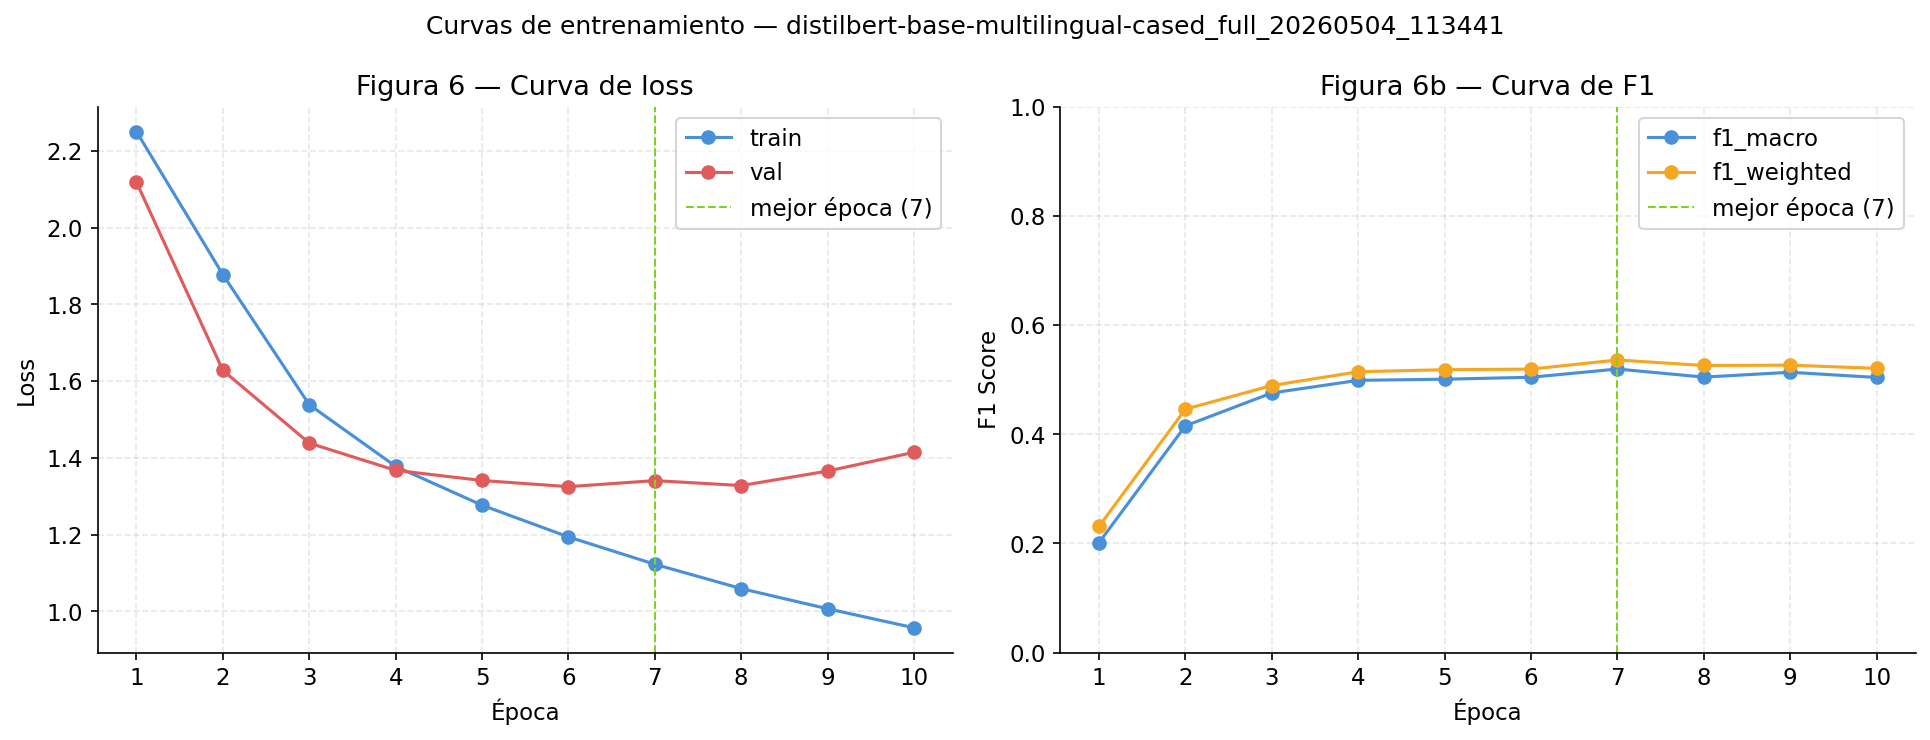

✓ Figura 6 guardada.


In [11]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Loss
ax1.plot(epochs_ran, history['train_loss'], 'o-', label='train', color='#4a90d9')
ax1.plot(epochs_ran, history['val_loss'],   'o-', label='val',   color='#e05c5c')
ax1.axvline(best_epoch, color='#7ed321', linestyle='--',
            linewidth=1, label=f'mejor época ({best_epoch})')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
fig_title(ax1, 'Figura 6 — Curva de loss')
ax1.legend()
ax1.set_xticks(epochs_ran)

# F1
ax2.plot(epochs_ran, history['f1_macro'],    'o-', label='f1_macro',    color='#4a90d9')
ax2.plot(epochs_ran, history['f1_weighted'], 'o-', label='f1_weighted', color='#f5a623')
ax2.axvline(best_epoch, color='#7ed321', linestyle='--',
            linewidth=1, label=f'mejor época ({best_epoch})')
ax2.set_xlabel('Época')
ax2.set_ylabel('F1 Score')
fig_title(ax2, 'Figura 6b — Curva de F1')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.set_xticks(epochs_ran)

mode_tag = 'smoke' if SMOKE_TEST else 'full'
fig.suptitle(f'Curvas de entrenamiento — {CFG["run_name"]}', fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / f'fig06_training_curves_{mode_tag}.png')
fig.savefig(FIG_DIR / f'fig06_training_curves_{mode_tag}.pdf')
plt.show()
print('✓ Figura 6 guardada.')

## 8. Evaluación final sobre test set

Se carga el **mejor checkpoint** (no el modelo del último epoch) para la evaluación final.

In [12]:
# ── Cargar mejor checkpoint ───────────────────────────────────────────────────
best_model = DistilBertForSequenceClassification.from_pretrained(
    run_dir / 'best_model'
).to(DEVICE)

test_metrics = evaluate(best_model, test_loader, criterion, DEVICE, GROUP_NAMES)

print('═' * 55)
print('EVALUACIÓN FINAL — TEST SET')
print('═' * 55)
print(f'  Loss:         {test_metrics["loss"]:.4f}')
print(f'  F1 Macro:     {test_metrics["f1_macro"]:.4f}')
print(f'  F1 Weighted:  {test_metrics["f1_weighted"]:.4f}')
print()
print('F1 por clase:')
for name, f1 in zip(GROUP_NAMES, test_metrics['f1_per_class']):
    bar = '█' * int(f1 * 20)
    flag = '  ⚠' if f1 < 0.5 else ''
    print(f'  {name:<14} {f1:.3f}  {bar}{flag}')

# Guardar métricas
test_results = {
    'run_name':       CFG['run_name'],
    'smoke_test':     SMOKE_TEST,
    'best_epoch':     best_epoch,
    'best_val_f1':    best_f1,
    'test_loss':      test_metrics['loss'],
    'test_f1_macro':  test_metrics['f1_macro'],
    'test_f1_weighted': test_metrics['f1_weighted'],
    'test_f1_per_class': dict(zip(GROUP_NAMES, test_metrics['f1_per_class'])),
    'config': CFG,
}
with open(run_dir / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)
print(f'\n✓ Métricas guardadas en {run_dir / "test_results.json"}')

═══════════════════════════════════════════════════════
EVALUACIÓN FINAL — TEST SET
═══════════════════════════════════════════════════════
  Loss:         1.3446
  F1 Macro:     0.5227
  F1 Weighted:  0.5323

F1 por clase:
  joy            0.608  ████████████
  love           0.702  ██████████████
  admiration     0.530  ██████████
  optimism       0.481  █████████  ⚠
  curiosity      0.557  ███████████
  sadness        0.505  ██████████
  anger          0.460  █████████  ⚠
  disgust        0.362  ███████  ⚠
  fear           0.532  ██████████
  neutral        0.489  █████████  ⚠

✓ Métricas guardadas en models/distilbert-base-multilingual-cased_full_20260504_113441/test_results.json


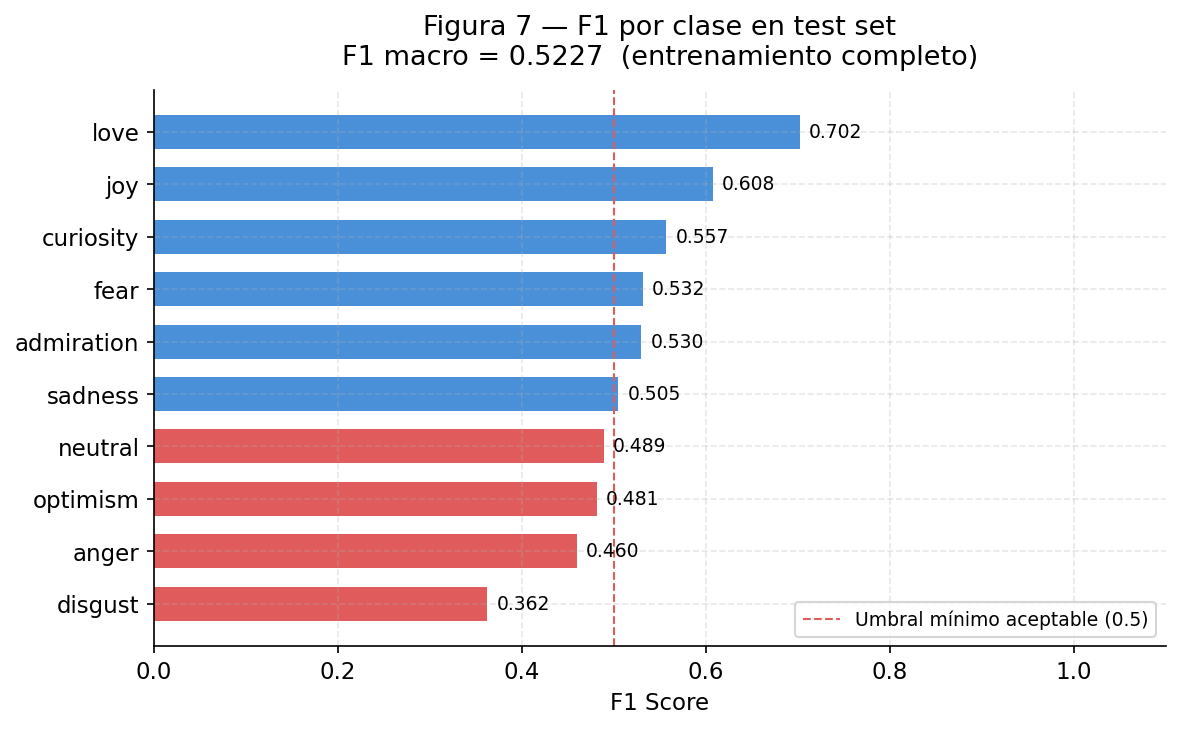

✓ Figura 7 guardada.


In [13]:
# ── Figura 7: F1 por clase (test set) ─────────────────────────────────────────
f1_df = pd.DataFrame({
    'emotion': GROUP_NAMES,
    'f1':      test_metrics['f1_per_class'],
}).sort_values('f1')

colors = ['#e05c5c' if f < 0.5 else '#4a90d9' for f in f1_df['f1']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(f1_df['emotion'], f1_df['f1'], color=colors,
               edgecolor='none', height=0.65)
ax.axvline(0.5, color='#e05c5c', linestyle='--', linewidth=1,
           label='Umbral mínimo aceptable (0.5)')
for bar, val in zip(bars, f1_df['f1']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=9)
ax.set_xlim(0, 1.1)
ax.set_xlabel('F1 Score')
fig_title(ax, f'Figura 7 — F1 por clase en test set\n'
             f'F1 macro = {test_metrics["f1_macro"]:.4f}  '
             f'({"SMOKE TEST" if SMOKE_TEST else "entrenamiento completo"})',
             pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / f'fig07_f1_per_class_{mode_tag}.png')
fig.savefig(FIG_DIR / f'fig07_f1_per_class_{mode_tag}.pdf')
plt.show()
print('✓ Figura 7 guardada.')

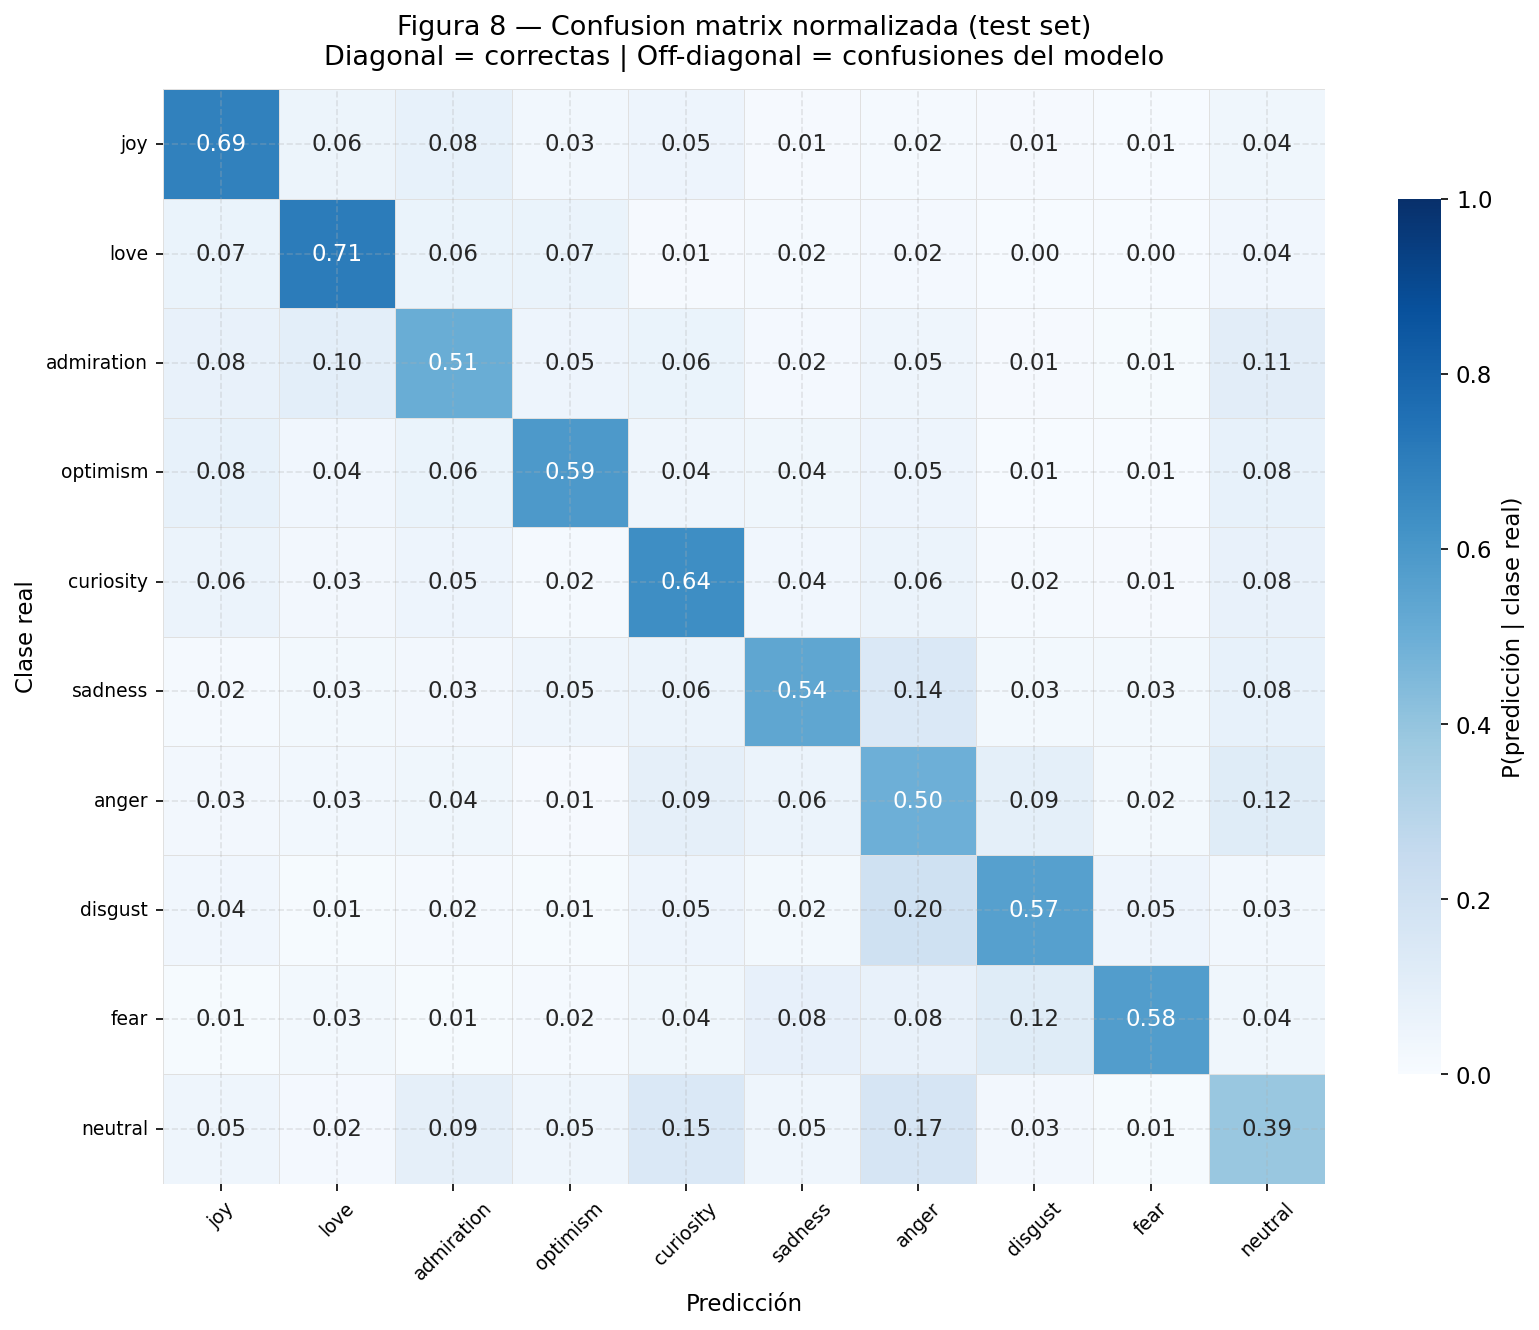

✓ Figura 8 guardada.

→ Las confusiones off-diagonal revelan qué clases el modelo mezcla.
  Si hay bloques sistemáticos, son candidatos a colapso adicional.


In [14]:
# ── Figura 8: Confusion matrix (test set) ─────────────────────────────────────
cm = confusion_matrix(
    test_metrics['labels'], test_metrics['preds'],
    labels=list(range(N_CLASSES)),
    normalize='true',   # normalizar por fila: P(pred | real)
)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=GROUP_NAMES, yticklabels=GROUP_NAMES,
    linewidths=0.4, linecolor='#e0e0e0',
    vmin=0, vmax=1, ax=ax,
    cbar_kws={'label': 'P(predicción | clase real)', 'shrink': 0.8},
)
ax.set_xlabel('Predicción')
ax.set_ylabel('Clase real')
fig_title(ax, 'Figura 8 — Confusion matrix normalizada (test set)\n'
             'Diagonal = correctas | Off-diagonal = confusiones del modelo', pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / f'fig08_confusion_matrix_{mode_tag}.png', bbox_inches='tight')
fig.savefig(FIG_DIR / f'fig08_confusion_matrix_{mode_tag}.pdf', bbox_inches='tight')
plt.show()
print('✓ Figura 8 guardada.')
print('\n→ Las confusiones off-diagonal revelan qué clases el modelo mezcla.')
print('  Si hay bloques sistemáticos, son candidatos a colapso adicional.')

In [15]:
# ── Classification report completo ───────────────────────────────────────────
report = classification_report(
    test_metrics['labels'], test_metrics['preds'],
    target_names=GROUP_NAMES, zero_division=0
)
print('Classification report (test set):')
print(report)

# Guardar como texto para el paper
with open(run_dir / 'classification_report.txt', 'w') as f:
    f.write(f'Run: {CFG["run_name"]}\n')
    f.write(f'Modo: {"SMOKE TEST" if SMOKE_TEST else "COMPLETO"}\n\n')
    f.write(report)
print(f'✓ Report guardado en {run_dir / "classification_report.txt"}')

Classification report (test set):
              precision    recall  f1-score   support

         joy       0.54      0.69      0.61      1056
        love       0.70      0.71      0.70      1450
  admiration       0.56      0.51      0.53      1742
    optimism       0.41      0.59      0.48       560
   curiosity       0.49      0.64      0.56      1446
     sadness       0.48      0.54      0.51       738
       anger       0.43      0.50      0.46      1570
     disgust       0.27      0.57      0.36       246
        fear       0.49      0.58      0.53       276
     neutral       0.66      0.39      0.49      3574

    accuracy                           0.53     12658
   macro avg       0.50      0.57      0.52     12658
weighted avg       0.56      0.53      0.53     12658

✓ Report guardado en models/distilbert-base-multilingual-cased_full_20260504_113441/classification_report.txt


## 9. Resumen del experimento

> Si `SMOKE_TEST = True`, los resultados de esta sección son de referencia para verificar
> que el pipeline funciona, **no** son los resultados finales a reportar en el paper.
> Repetir con `SMOKE_TEST = False` para los resultados definitivos.

In [16]:
print('═' * 60)
print(f'RESUMEN — Notebook 02: Fine-tuning DistilBERT')
print(f'Modo: {"🧪 SMOKE TEST (resultados no finales)" if SMOKE_TEST else "🚀 COMPLETO"}')
print('═' * 60)
print(f"""
MODELO
  Base:               {CFG['model_name']}
  Clases:             {N_CLASSES} ({', '.join(GROUP_NAMES)})
  Parámetros:         {total_params:,}

ENTRENAMIENTO
  Épocas ejecutadas:  {len(history['train_loss'])}
  Mejor época:        {best_epoch}
  Mejor val f1_macro: {best_f1:.4f}
  Early stopping:     patience={CFG['patience']}

TEST SET
  Loss:               {test_metrics['loss']:.4f}
  F1 Macro:           {test_metrics['f1_macro']:.4f}
  F1 Weighted:        {test_metrics['f1_weighted']:.4f}

ARTEFACTOS
  Modelo:             {run_dir / 'best_model'}
  Historial:          {run_dir / 'history.json'}
  Métricas test:      {run_dir / 'test_results.json'}
  Report:             {run_dir / 'classification_report.txt'}

SIGUIENTE PASO
  Notebook 03: Exportación a ONNX con cuantización INT8,
  benchmark de latencia CPU y construcción del EmotionDetector
  con interfaz de streaming (push/flush + EmotionEvent bus).
""")
print('═' * 60)

════════════════════════════════════════════════════════════
RESUMEN — Notebook 02: Fine-tuning DistilBERT
Modo: 🚀 COMPLETO
════════════════════════════════════════════════════════════

MODELO
  Base:               distilbert-base-multilingual-cased
  Clases:             10 (joy, love, admiration, optimism, curiosity, sadness, anger, disgust, fear, neutral)
  Parámetros:         135,332,362

ENTRENAMIENTO
  Épocas ejecutadas:  10
  Mejor época:        7
  Mejor val f1_macro: 0.5195
  Early stopping:     patience=3

TEST SET
  Loss:               1.3446
  F1 Macro:           0.5227
  F1 Weighted:        0.5323

ARTEFACTOS
  Modelo:             models/distilbert-base-multilingual-cased_full_20260504_113441/best_model
  Historial:          models/distilbert-base-multilingual-cased_full_20260504_113441/history.json
  Métricas test:      models/distilbert-base-multilingual-cased_full_20260504_113441/test_results.json
  Report:             models/distilbert-base-multilingual-cased_full_20260

### Observación
La emoción "Disgust" tiene baja precisión, es decir, se predice con demasiada libertad, esto se resolverá implementando un sistema de predicción basado en thresholds y no simplement en argmax como se hacia antes. 
Primero buscaré el threshold optimo para disgust y luego probaré a re-evaluar el modelo para ver si hay mejoría

In [17]:
import pandas as pd
import numpy as np

# test_metrics viene de la celda de evaluación final
preds  = np.array(test_metrics['preds'])
labels = np.array(test_metrics['labels'])

disgust_id = GROUP2ID['disgust']

# Falsos positivos: predichos como disgust pero no son disgust
fp_mask    = (preds == disgust_id) & (labels != disgust_id)
fp_labels  = labels[fp_mask]

print(f'Total predicciones como disgust: {(preds == disgust_id).sum()}')
print(f'Verdaderos positivos:            {((preds == disgust_id) & (labels == disgust_id)).sum()}')
print(f'Falsos positivos:                {fp_mask.sum()}')
print()
print('Clases reales de los falsos positivos:')
for class_id, count in sorted(zip(*np.unique(fp_labels, return_counts=True)), 
                               key=lambda x: -x[1]):
    print(f'  {GROUP_NAMES[class_id]:<14} {count}')

Total predicciones como disgust: 521
Verdaderos positivos:            139
Falsos positivos:                382

Clases reales de los falsos positivos:
  anger          149
  neutral        108
  fear           33
  curiosity      26
  admiration     24
  sadness        20
  joy            13
  love           6
  optimism       3


In [18]:
# Recolectar probabilidades de disgust en los falsos positivos
# Sobre VALIDATION: este análisis alimenta la calibración del threshold,
# así que no debe tocar el test set.
best_model.eval()
disgust_probs_fp = []
disgust_probs_tp = []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        batch_labels   = batch['label']

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=-1).cpu()
        preds_b = probs.argmax(dim=-1)

        for prob, pred, label in zip(probs, preds_b, batch_labels):
            if pred.item() == disgust_id:
                p = prob[disgust_id].item()
                if label.item() == disgust_id:
                    disgust_probs_tp.append(p)
                else:
                    disgust_probs_fp.append(p)

print(f'Prob disgust en verdaderos positivos — media: {np.mean(disgust_probs_tp):.3f}  '
      f'min: {np.min(disgust_probs_tp):.3f}  p25: {np.percentile(disgust_probs_tp, 25):.3f}')
print(f'Prob disgust en falsos positivos    — media: {np.mean(disgust_probs_fp):.3f}  '
      f'min: {np.min(disgust_probs_fp):.3f}  p25: {np.percentile(disgust_probs_fp, 25):.3f}')

Prob disgust en verdaderos positivos — media: 0.818  min: 0.246  p25: 0.729
Prob disgust en falsos positivos    — media: 0.659  min: 0.244  p25: 0.484


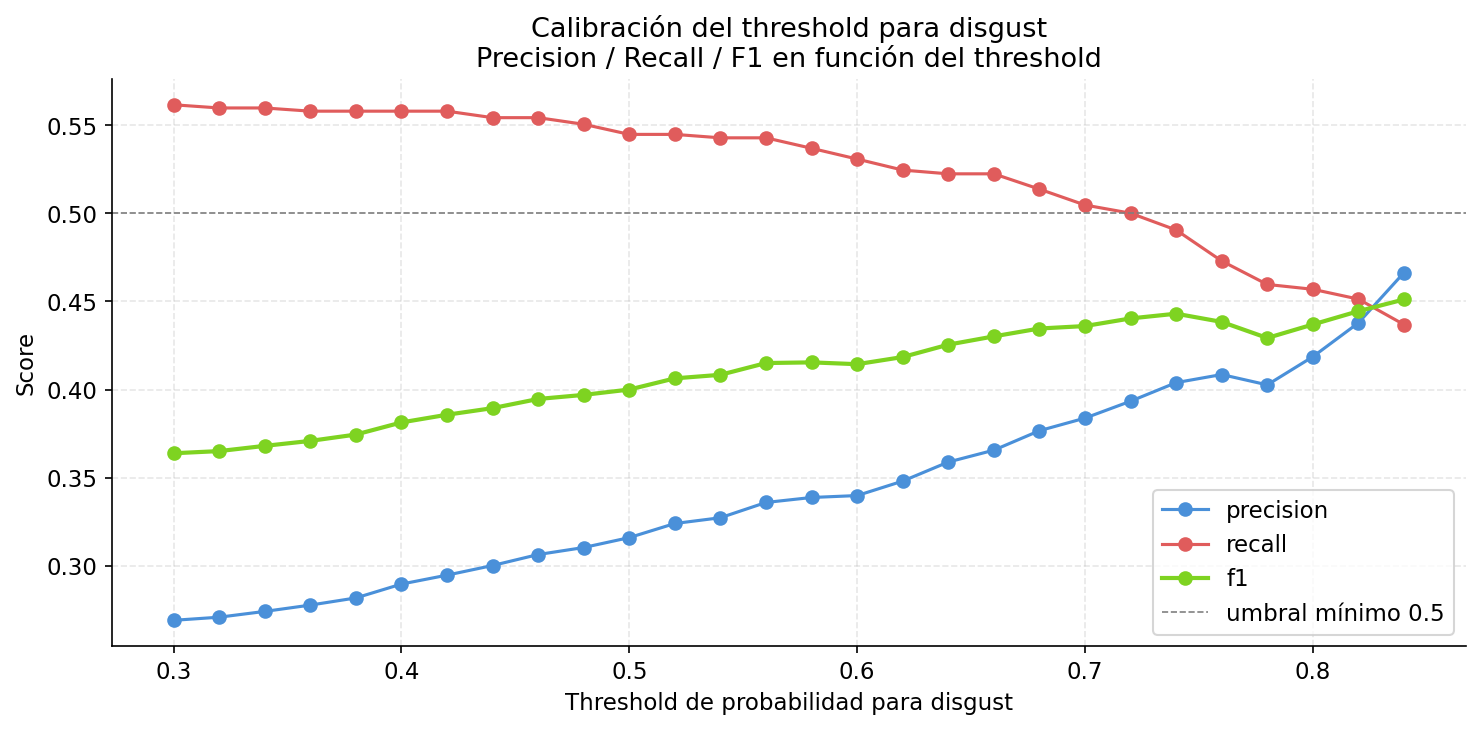


Mejor threshold por F1:
  threshold: 0.84
  precision: 0.466
  recall:    0.437
  f1:        0.451


In [19]:
import matplotlib.pyplot as plt

# Barrer thresholds y calcular precision/recall/f1 para disgust.
# IMPORTANTE: la calibración se hace sobre VALIDATION, no sobre test,
# para no contaminar la métrica final reportada en test.
thresholds_to_try = np.arange(0.30, 0.85, 0.02)
results = []

all_probs_val  = []
all_labels_val = []

best_model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

        all_probs_val.append(probs)
        all_labels_val.extend(batch['label'].tolist())

all_probs_val  = np.concatenate(all_probs_val)
all_labels_val = np.array(all_labels_val)
base_preds_val = all_probs_val.argmax(axis=1)

for t in thresholds_to_try:
    preds_t = base_preds_val.copy()

    # Si la predicción es disgust pero no supera el threshold, reasignar a la
    # segunda clase más probable — igual que predict_with_threshold en producción
    demote = (preds_t == disgust_id) & (all_probs_val[:, disgust_id] < t)
    if demote.any():
        probs_masked = all_probs_val[demote].copy()
        probs_masked[:, disgust_id] = -1
        preds_t[demote] = probs_masked.argmax(axis=1)

    tp = ((preds_t == disgust_id) & (all_labels_val == disgust_id)).sum()
    fp = ((preds_t == disgust_id) & (all_labels_val != disgust_id)).sum()
    fn = ((preds_t != disgust_id) & (all_labels_val == disgust_id)).sum()

    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    results.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1})

results_df = pd.DataFrame(results)

# Figura
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['threshold'], results_df['precision'], 'o-', label='precision', color='#4a90d9')
ax.plot(results_df['threshold'], results_df['recall'],    'o-', label='recall',    color='#e05c5c')
ax.plot(results_df['threshold'], results_df['f1'],        'o-', label='f1',        color='#7ed321', linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='umbral mínimo 0.5')
ax.set_xlabel('Threshold de probabilidad para disgust')
ax.set_ylabel('Score')
ax.set_title('Calibración del threshold para disgust (validation set)\n'
             'Precision / Recall / F1 en función del threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Mejor threshold por F1 (calibrado en validation)
best_row = results_df.loc[results_df['f1'].idxmax()]
print(f'\nMejor threshold por F1 (validation):')
print(f'  threshold: {best_row["threshold"]:.2f}')
print(f'  precision: {best_row["precision"]:.3f}')
print(f'  recall:    {best_row["recall"]:.3f}')
print(f'  f1:        {best_row["f1"]:.3f}')


## Re-evaluar el modelo

In [20]:
# ── Re-evaluación con threshold calibrado ─────────────────────────────────────
# El threshold de disgust fue calibrado mediante barrido P/R/F1 sobre el
# VALIDATION set (celda anterior); aquí se reporta su efecto en test.
# Tras re-entrenar, actualizar este valor con el del nuevo barrido.

THRESHOLDS = {'disgust': 0.68}

def predict_with_threshold(logits, group_names, thresholds):
    probs       = torch.softmax(logits, dim=-1)
    base_preds  = probs.argmax(dim=-1)
    final_preds = base_preds.clone()

    for i, (prob_row, base_pred) in enumerate(zip(probs, base_preds)):
        class_name = group_names[base_pred.item()]
        if class_name in thresholds:
            if prob_row[base_pred].item() < thresholds[class_name]:
                prob_row_masked          = prob_row.clone()
                prob_row_masked[base_pred] = -1
                final_preds[i]           = prob_row_masked.argmax()

    return final_preds

# Recolectar predicciones con threshold
best_model.eval()
all_preds_t, all_labels_t = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        preds_t = predict_with_threshold(outputs.logits, GROUP_NAMES, THRESHOLDS)

        all_preds_t  += preds_t.cpu().tolist()
        all_labels_t += batch['label'].tolist()

# Métricas
f1_macro_t   = f1_score(all_labels_t, all_preds_t, average='macro',    zero_division=0)
f1_weighted_t = f1_score(all_labels_t, all_preds_t, average='weighted', zero_division=0)
report_t     = classification_report(all_labels_t, all_preds_t,
                                     target_names=GROUP_NAMES, zero_division=0)

print('═' * 55)
print('RE-EVALUACIÓN CON THRESHOLD CALIBRADO')
print('═' * 55)
print(f'  F1 Macro:     {f1_macro_t:.4f}  (antes: {test_metrics["f1_macro"]:.4f})')
print(f'  F1 Weighted:  {f1_weighted_t:.4f}  (antes: {test_metrics["f1_weighted"]:.4f})')
print()
print(report_t)

# Guardar
with open(run_dir / 'classification_report_thresholded.txt', 'w') as f:
    f.write(f'Run: {CFG["run_name"]}\n')
    f.write(f'Thresholds aplicados: {THRESHOLDS}\n\n')
    f.write(report_t)

print(f'✓ Report guardado en {run_dir / "classification_report_thresholded.txt"}')

═══════════════════════════════════════════════════════
RE-EVALUACIÓN CON THRESHOLD CALIBRADO
═══════════════════════════════════════════════════════
  F1 Macro:     0.5301  (antes: 0.5227)
  F1 Weighted:  0.5362  (antes: 0.5323)

              precision    recall  f1-score   support

         joy       0.54      0.69      0.61      1056
        love       0.70      0.71      0.70      1450
  admiration       0.56      0.51      0.53      1742
    optimism       0.41      0.59      0.48       560
   curiosity       0.49      0.64      0.56      1446
     sadness       0.47      0.54      0.50       738
       anger       0.43      0.53      0.47      1570
     disgust       0.38      0.46      0.41       246
        fear       0.48      0.61      0.54       276
     neutral       0.66      0.39      0.49      3574

    accuracy                           0.54     12658
   macro avg       0.51      0.57      0.53     12658
weighted avg       0.56      0.54      0.54     12658

✓ Report g